In [4]:
import threading
import json
import time
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
import sklearn.cluster
import skimage
from skimage import morphology
import argparse
import matplotlib.cm as cm


In [5]:
def get_edge_count(image):
    edges = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(edges, 100, 200) 
    return np.sum(edges > 30)


(1996, 2920)
Resized image from 2920x1996 to 2048x1399
Edge count: 31669
Time taken: 0.008098125457763672 seconds


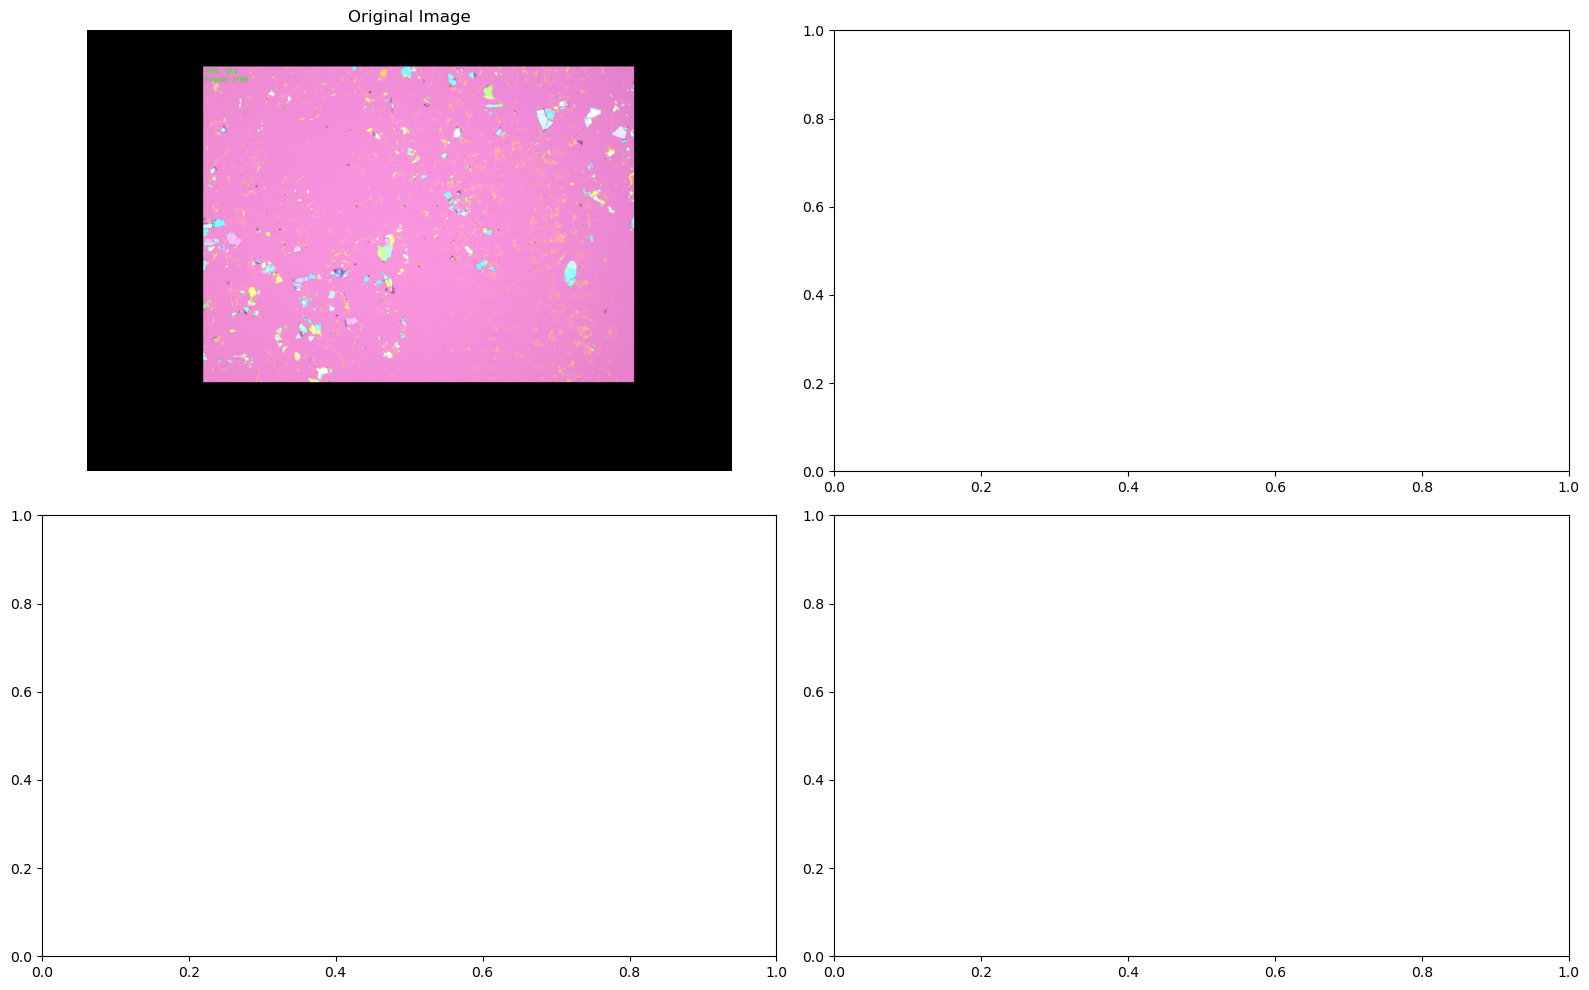

In [6]:
image_name = 'image'
image = cv2.imread(f'{image_name}.png', cv2.IMREAD_COLOR)
    
height, width = image.shape[:2]
print(image.shape[:2])
if max(height, width) > 2048:
    scale = 2048 / max(height, width)
    new_width = int(width * scale)
    new_height = int(height * scale)
    image_good = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)
    print(f"Resized image from {width}x{height} to {new_width}x{new_height}")
    height, width = new_height, new_width
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original image
axes[0, 0].imshow(image)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

timestamp = time.time()
edge_count = get_edge_count(image)
print(f"Edge count: {edge_count}")
print(f"Time taken: {time.time() - timestamp} seconds")

# # Gray World method
# image1 = image
# axes[0, 1].imshow(image1)
# axes[0, 1].set_title('Original Image')
# axes[0, 1].axis('off')

# # Max White method
# image_2 = transform_1(image_good, image_bad)
# axes[1, 1].imshow(image_2)
# axes[1, 1].set_title('2')
# axes[1, 1].axis('off')

# axes[1, 2].axis('off')

plt.tight_layout()
plt.show()